Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import csv

Carga imagen ideal con monedas y convierte a RGB

(938, 473, 3)


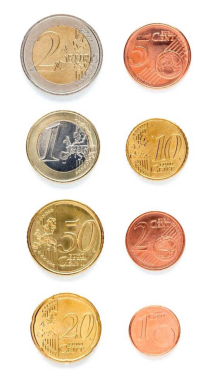

In [3]:
# Carga imagen ejemplo con monedas
img = cv2.imread('Monedas.jpg') 
print(img.shape) 

# OpenCV lee las imágenes en BGR -> convertimos para visualizar a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.axis("off")
plt.imshow(img_rgb) 
plt.show()

Convierte a gris y muestra histograma

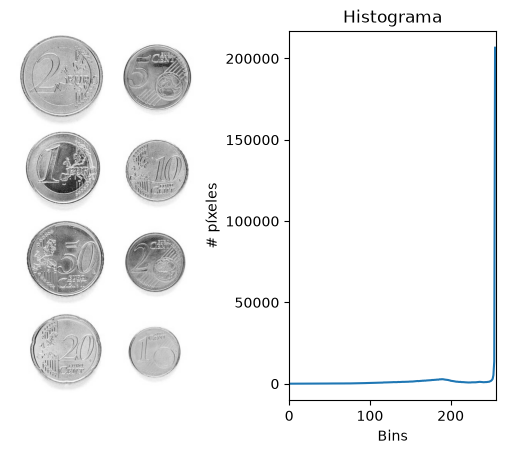

In [4]:
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Histograma con 256 bins para una imagen en escala de grises
hist = cv2.calcHist([img_gris], [0], None, [256], [0, 256])

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.imshow(img_gris, cmap='gray')

# Histograma sin normalizar
plt.subplot(1, 2, 2)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("# píxeles")
plt.plot(hist)
plt.xlim([0, 256])

# Separar subplots horizontalmente
plt.subplots_adjust(wspace=0.4)

Cuenta resultado tras umbralizar (poniendo a negro el fondo)

Umbral fijo usado  200.0
Umbral Otsu  204.0


Text(0.5, 1.0, 'OTSU invertida')

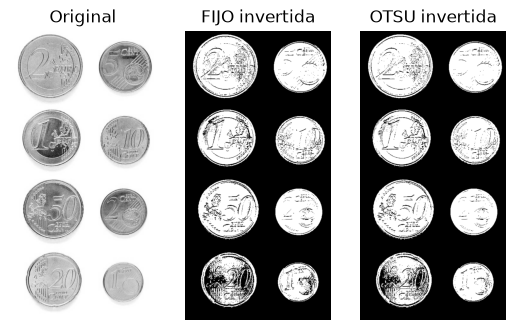

In [5]:
# Dos variantes de umbralizado. Probar otros parámetros, aplicar filtro previo, etc.
umbral = 200 # Prueba varios comenzando en 130

# Umbralizado binario invertido (dado que por defecto se asume objetos en blanco)
th1, img_th1 = cv2.threshold(img_gris,umbral, 255, cv2.THRESH_BINARY_INV)
print('Umbral fijo usado ', th1)

# Umbralizado con método de Otsu (selección automática del umbral)
th2, img_th2 = cv2.threshold(img_gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print('Umbral Otsu ', th2)

plt.subplot(1, 3, 1)
plt.axis("off")
plt.imshow(img_gris,cmap='gray') 
plt.title('Original')

plt.subplot(1, 3, 2)
plt.axis("off")
plt.imshow(img_th1,cmap='gray') 
plt.title('FIJO invertida')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.imshow(img_th2,cmap='gray') 
plt.title('OTSU invertida')

Búsqueda de componentes y sus contornos

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


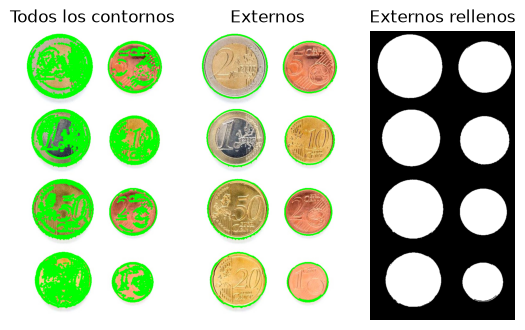

In [6]:
# Localiza contornos en imagen obtenida con umbral fijo
# findContours está diseñada para imágenes con  figura en blanco y fondo negro
# La imagen de entrada debe ser de un canal y 8 bits excepto en los modos RETR_CCOMP o RETR_FLOODFILL
# hierarchy contiene información sobre el nivel del contorno, relaciones paterno-filiales (contornos contenidos en otros)

# Obtiene todos los contornos: externos e internos
contornos, hierarchy = cv2.findContours(
    img_th1,
    cv2.RETR_TREE,              # modo de recuperación (lista, árbol, nivel superior...)
    cv2.CHAIN_APPROX_SIMPLE     # método de aproximación del contorno
)

# Dibuja sobre la imagen de entrada los contornos en verde
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.drawContours(img_rgb, contornos, -1, (0,255,0), 3)

plt.subplot(131)
plt.axis("off")
plt.imshow(img_rgb) 
plt.title('Todos los contornos')

# Contornos externos
contornos2, hierarchy2 = cv2.findContours(img_th1, 
    cv2.RETR_EXTERNAL , 
    cv2.CHAIN_APPROX_SIMPLE
)

# Dibuja sobre la imagen de entrada sólo contornos externos
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.drawContours(img_rgb, contornos2, -1, (0,255,0), 3)

plt.subplot(132)
plt.axis("off")
plt.imshow(img_rgb) 
plt.title('Externos')

# Dibuja contornos externos rellenos en imagen vacía
# Imagen negra
img_cont = np.zeros(img_rgb.shape)
for c in contornos2:
    area = cv2.contourArea(c)
    #Área mínima (útil filtrar en ocasiones)
    if area > 10:
        perimetro = cv2.arcLength(c,True)
        x,y,w,h = cv2.boundingRect(c)
        rect = cv2.minAreaRect(c)
        # Mínimo círculo que contiene al contorno
        (cx,cy),radio = cv2.minEnclosingCircle(c)

        # Elipse ajustada al contorno, exigiendo un mínimo de puntos del contornos
        if c.shape[0] > 5:
            elipse = cv2.fitEllipse(c)
            #print(area, perimetro, rect, cx,cy,radio, elipse)

        #Dibuja los contornos
        cv2.drawContours(img_cont, [c], -1, (255,255,255), -1)

plt.subplot(133)
plt.axis("off")
plt.imshow(img_cont) 
plt.title('Externos rellenos')
plt.show()


Alternativa contando círculos utilizando la Transformada de Hough. La selección de parámetros puede ser "divertida", más [información](https://docs.opencv.org/4.x/da/d53/tutorial_py_houghcircles.html)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


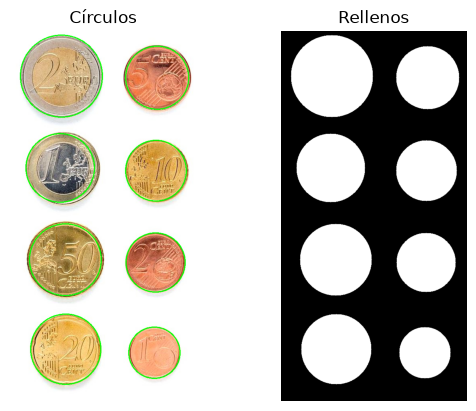

In [7]:
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
pimg = cv2.medianBlur(gris, 7)                  # Suaviza imagen (elimina altas frecuencias)

# Localiza Círculos
circ = cv2.HoughCircles(
        pimg,
        cv2.HOUGH_GRADIENT,  # tipo de detección
        1,
        100,                 # distancia mínima entre círculos
        param1=100,          # valor del gradiente
        param2=50,           # umbral acumulador
        minRadius=50,        # radio mínimo
        maxRadius=150,       # radio máximo
)

# Dibuja sobre entrada e imagen vacía
img_cont = np.zeros(img_rgb.shape)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for det in circ[0]:
        x_coor, y_coor, det_radio = det
        cv2.circle(img_rgb,(int(x_coor), int(y_coor)),
            int(det_radio),(0, 255, 0), 2)
        cv2.circle(img_cont,(int(x_coor), int(y_coor)),
            int(det_radio),(255, 255, 255), -1)

plt.subplot(121)
plt.axis("off")
plt.imshow(img_rgb) 
plt.title('Círculos')

plt.subplot(122)
plt.axis("off")
plt.imshow(img_cont) 
plt.title('Rellenos')

plt.show()

Las formas localizadas tienen distintas características geométricas, que pueden estimarse a partir de sus contornos. Más información en la [documentación de OpenCV](https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html).

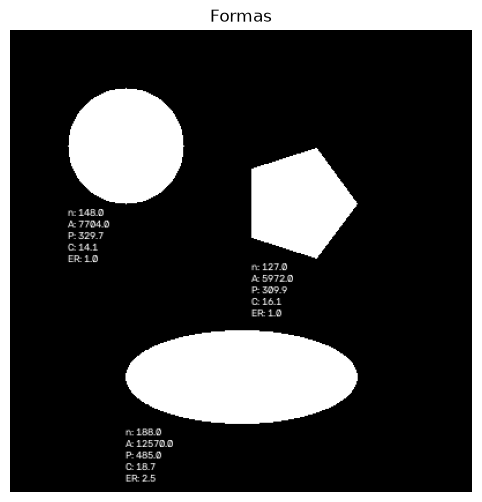

In [8]:
# Creación de polígono regular
def poligono_regular(image, ctr, radio, lados, color):
    pts = []
    ang_step = 2 * np.pi / lados

    for i in range(lados):
        ang = i * ang_step
        x = int(ctr[0] + radio * np.cos(ang))
        y = int(ctr[1] + radio * np.sin(ang))
        pts.append((x, y))

    pts = np.array(pts, np.int32)
    pts = pts.reshape((-1, 1, 2))
    cv2.fillPoly(image, [pts], color=color)

# Imagen vacía
img = np.zeros((400, 400, 1), dtype="uint8")
color = (255, 255, 255)

# Formas básicas
cv2.circle(img, (100, 100), 50, color, -1)       # Circular
poligono_regular(img, (250, 150), 50, 5, color)  # Polígono regular
cv2.ellipse(img, (200, 300), (100, 40), 0, 0, 360, color, -1)  # Elíptica

# Localiza contornos
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Parámeros texto
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.3
thickness = 1

# Process each contour to calculate compactness and ellipse ratio (if possible)
for c in contours:
    clon = len(c)
    area = cv2.contourArea(c)
    perimetro = cv2.arcLength(c, True)

    # Contenedor alineado con ejes de la imagen
    x,y,w,h = cv2.boundingRect(c)
    
    # Compactness: 4*pi*Area/Perimeter^2
    if perimetro > 0:
        compacidad = (perimetro ** 2) / area
    else:
        compactness = 0
    
    # Ajusta elipse si hay suficientes puntos
    if clon >= 5:
        elipse = cv2.fitEllipse(c)
        (center, axes, orientation) = elipse
        major_axis = max(axes)
        minor_axis = min(axes)
        elipse_ratio = major_axis / minor_axis
    else:
        elipse_ratio = None
    
    # Muestra valores en imageb
    cv2.putText(img, f"n: {clon:.1f}", (x, int(y+h+10)), font, font_scale, (255, 255, 255), thickness)
    cv2.putText(img, f"A: {area:.1f}", (x, int(y+h+20)), font, font_scale, (255, 255, 255), thickness)
    cv2.putText(img, f"P: {perimetro:.1f}", (x, int(y+h+30)), font, font_scale, color, thickness)
    cv2.putText(img, f"C: {compacidad:.1f}", (x, int(y+h+40)), font, font_scale, color, thickness)
    cv2.putText(img, f"ER: {elipse_ratio:.1f}", (x, int(y+h+50)), font, font_scale, color, thickness)
    
# Visualiza la imagen
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Formas")
plt.axis('off')
plt.show()


TAREA: Los ejemplos anteriores permiten saber el nº de monedas de la imagen ideal proporcionada. ¿Cómo determinar la cantidad de dinero presente en ella? 

A partir de las dimensiones, una sugerencia es identificar de forma interactiva (por ejemplo haciendo clic en la imagen) una moneda de un valor fijo en la imagen (por ejemplo de 1€) para permitir establecer una relación entre píxeles y milímetros. 
Tras obtener esa información y las dimensiones en milímetros de las distintas monedas, es factible calcular la cantidad de dinero en la imagen ideal.

Tras resolver el reto con la imagen ideal, diseña un demostrador en vivo que, a partir de la entrada de vídeo de la cámara, determine el dinero presente en la escena. 
Si bien no hay restricciones sobre utilizar medidas geométricas o de color, o cualquier clasificador, no deben hacer uso de modelos de aprendizaje profundo. ¿Funciona correctamente? ¿Se observan problemas?
Posibles extras serían la presencia de objetos que no son monedas y/o haya solape entre las monedas.

IMPORTANTE: No usar de modelos de aprendizaje profundo

Nota: Para establecer la correspondencia entre píxeles y milímetros, comentar que la moneda de un euro tiene un diámetro de 23.25 mm. la de 50 céntimos de 24.35, la de 20 céntimos de 22.25, etc. 

In [ ]:
%pip install ipympl
%matplotlib widget
%matplotlib inline

Parte 1 (clasificador con imagen ideal)

Círculos detectados inicialmente: 8
Círculos finales: 8
Selecciona dos extremos opuestos de una moneda de 1 euro.
Pulsa ESC para cancelar.
Diámetro de referencia: 178.00 píxeles
Escala: 7.656 píxeles/mm
Moneda 1: 2 euros | Diámetro: 26.12 mm | Diferencia: 0.37 mm
Moneda 2: 50 céntimos | Diámetro: 24.03 mm | Diferencia: 0.22 mm
Moneda 3: 1 euro | Diámetro: 23.25 mm | Diferencia: 0.00 mm
Moneda 4: 20 céntimos | Diámetro: 22.21 mm | Diferencia: 0.04 mm
Moneda 5: 5 céntimos | Diámetro: 21.16 mm | Diferencia: 0.09 mm
Moneda 6: 10 céntimos | Diámetro: 19.85 mm | Diferencia: 0.10 mm
Moneda 7: 2 céntimos | Diámetro: 19.07 mm | Diferencia: 0.32 mm
Moneda 8: 1 céntimo | Diámetro: 16.72 mm | Diferencia: 0.47 mm


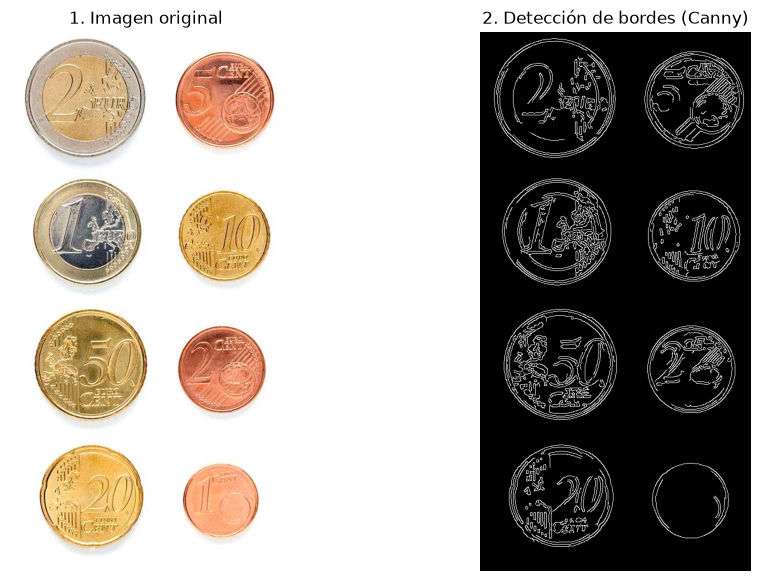

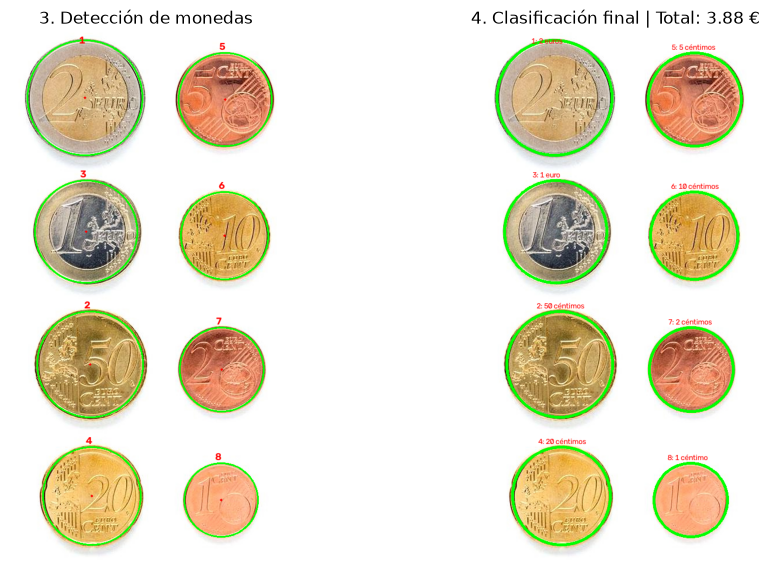


RESUMEN
Número de monedas detectadas: 8
Total de monedas: 3.88 €


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CARGAR IMAGEN Y DETECTAR BORDES
# ============================================================

img = cv2.imread("Monedas.jpg")
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gris_suave = cv2.GaussianBlur(gris, (5, 5), 1.5)
bordes = cv2.Canny(gris_suave, 50, 130)

# ============================================================
# 2. DETECCIÓN INICIAL DE CÍRCULOS
# ============================================================

circulos_detectados = cv2.HoughCircles(
    gris_suave,
    cv2.HOUGH_GRADIENT,
    dp=1.0,
    minDist=65,
    param1=130,
    param2=45,
    minRadius=40,
    maxRadius=150
)

if circulos_detectados is None:
    raise RuntimeError("No se han detectado círculos. Ajusta los parámetros de Hough.")

circulos = np.round(circulos_detectados[0]).astype(int)

print("Círculos detectados inicialmente:", len(circulos))


# ============================================================
# 3. REFINAR LOS CÍRCULOS CON LOS BORDES LOCALES
# ============================================================

def refinar_circulo(x, y, r, imagen_bordes):
    alto, ancho = imagen_bordes.shape
    margen = int(r * 0.25) + 3

    x1 = max(0, x - r - margen)
    x2 = min(ancho, x + r + margen + 1)
    y1 = max(0, y - r - margen)
    y2 = min(alto, y + r + margen + 1)

    recorte = imagen_bordes[y1:y2, x1:x2]
    yy, xx = np.where(recorte > 0)

    if len(xx) < 20:
        return x, y, r

    xx = xx + x1
    yy = yy + y1

    distancias = np.sqrt((xx - x) ** 2 + (yy - y) ** 2)
    seleccion = np.abs(distancias - r) < max(4, r * 0.12)

    px = xx[seleccion].astype(float)
    py = yy[seleccion].astype(float)

    if len(px) < 12:
        return x, y, r

    # Ajustar una circunferencia por mínimos cuadrados.
    matriz = np.column_stack((px, py, np.ones_like(px)))
    objetivo = -(px ** 2 + py ** 2)

    try:
        A, B, C = np.linalg.lstsq(
            matriz, objetivo, rcond=None
        )[0]
    except np.linalg.LinAlgError:
        return x, y, r

    cx = -A / 2
    cy = -B / 2
    radio2 = (A ** 2 + B ** 2) / 4 - C

    if radio2 <= 0:
        return x, y, r

    radio = np.sqrt(radio2)

    # Rechazar ajustes demasiado alejados de la detección inicial.
    if (
        abs(cx - x) > r * 0.12
        or abs(cy - y) > r * 0.12
        or abs(radio - r) > r * 0.15
    ):
        return x, y, r

    return int(round(cx)), int(round(cy)), int(round(radio))


circulos_refinados = [
    refinar_circulo(x, y, r, bordes)
    for x, y, r in circulos
]


# ============================================================
# 4. ELIMINAR DETECCIONES DUPLICADAS
# ============================================================

circulos_refinados.sort(key=lambda c: c[2], reverse=True)
circulos_finales = []

for x, y, r in circulos_refinados:
    duplicado = False

    for cx, cy, cr in circulos_finales:
        distancia = np.hypot(x - cx, y - cy)

        if (
            distancia < 0.55 * min(r, cr)
            and abs(r - cr) < 0.30 * max(r, cr)
        ):
            duplicado = True
            break

    if not duplicado:
        circulos_finales.append([x, y, r])

if not circulos_finales:
    raise RuntimeError("No quedan círculos válidos tras el refinamiento.")

circulos = np.array(circulos_finales, dtype=int)

print("Círculos finales:", len(circulos))


# ============================================================
# 5. DIBUJAR LOS CÍRCULOS DETECTADOS
# ============================================================

imagen_detecciones = img.copy()

for i, (x, y, r) in enumerate(circulos, start=1):
    cv2.circle(imagen_detecciones, (x, y), r, (0, 255, 0), 2)
    cv2.circle(imagen_detecciones, (x, y), 2, (0, 0, 255), -1)

    cv2.putText(
        imagen_detecciones,
        str(i),
        (x - 10, max(y - r - 5, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )


# ============================================================
# 6. CALIBRAR CON UNA MONEDA DE 1 EURO
# ============================================================

puntos = []
imagen_calibracion = img.copy()
ventana = "Selecciona dos extremos opuestos de una moneda de 1 euro"


def seleccionar_extremos(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(puntos) < 2:
        puntos.append((x, y))
        cv2.circle(imagen_calibracion, (x, y), 5, (0, 0, 255), -1)

        if len(puntos) == 2:
            cv2.line(imagen_calibracion, puntos[0], puntos[1], (0, 255, 0), 2)

        cv2.imshow(ventana, imagen_calibracion)


cv2.namedWindow(ventana)
cv2.setMouseCallback(ventana, seleccionar_extremos)
cv2.imshow(ventana, imagen_calibracion)

while len(puntos) < 2:
    if cv2.waitKey(20) & 0xFF == 27:
        break

cv2.destroyAllWindows()

if len(puntos) != 2:
    raise RuntimeError("Calibración cancelada.")

p1 = np.array(puntos[0], dtype=float)
p2 = np.array(puntos[1], dtype=float)
diametro_px = np.linalg.norm(p2 - p1)

if diametro_px == 0:
    raise RuntimeError("Los dos puntos seleccionados son iguales.")

# Diámetro oficial de una moneda de 1 euro: 23,25 mm.
escala = diametro_px / 23.25

print(f"Diámetro de referencia: {diametro_px:.2f} píxeles")
print(f"Escala: {escala:.3f} píxeles/mm")

# ============================================================
# 7. CLASIFICAR MONEDAS Y CALCULAR EL TOTAL
# ============================================================

monedas = {
    "1 céntimo": (16.25, 0.01),
    "2 céntimos": (18.75, 0.02),
    "5 céntimos": (21.25, 0.05),
    "10 céntimos": (19.75, 0.10),
    "20 céntimos": (22.25, 0.20),
    "50 céntimos": (24.25, 0.50),
    "1 euro": (23.25, 1.00),
    "2 euros": (25.75, 2.00)
}

total = 0.0
resultados = []

for i, (x, y, r) in enumerate(circulos, start=1):
    diametro_mm = (2 * r) / escala

    nombre, (diametro_oficial, valor) = min(
        monedas.items(),
        key=lambda item: abs(item[1][0] - diametro_mm)
    )

    diferencia = abs(diametro_oficial - diametro_mm)
    total += valor

    resultados.append((x, y, r, nombre, diametro_mm))

    print(
        f"Moneda {i}: {nombre} | "
        f"Diámetro: {diametro_mm:.2f} mm | "
        f"Diferencia: {diferencia:.2f} mm"
    )

# ============================================================
# 8. CREAR LA IMAGEN DE CLASIFICACIÓN FINAL
# ============================================================

imagen_final = img.copy()

for i, (x, y, r, nombre, diametro_mm) in enumerate(resultados, start=1):
    cv2.circle(imagen_final, (x, y), r, (0, 255, 0), 3)
    cv2.putText(
        imagen_final,
        f"{i}: {nombre}",
        (x - 40, max(y - r - 5, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 0, 255),
        1,
        cv2.LINE_AA
    )


# ============================================================
# 9. MOSTRAR LOS RESULTADOS EN DOS FIGURAS INDEPENDIENTES
# ============================================================

# FIGURA 1: Imagen original y detección de bordes
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 7))

ax1[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1[0].set_title("1. Imagen original")

ax1[1].imshow(bordes, cmap="gray")
ax1[1].set_title("2. Detección de bordes (Canny)")

for a in ax1:
    a.axis("off")

fig1.subplots_adjust(wspace=0.02)
plt.show()


# FIGURA 2: Detección de monedas y clasificación final
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 7))

ax2[0].imshow(cv2.cvtColor(imagen_detecciones, cv2.COLOR_BGR2RGB))
ax2[0].set_title("3. Detección de monedas")

ax2[1].imshow(cv2.cvtColor(imagen_final, cv2.COLOR_BGR2RGB))
ax2[1].set_title(f"4. Clasificación final | Total: {total:.2f} €")

for a in ax2:
    a.axis("off")

fig2.subplots_adjust(wspace=0.02)
plt.show()

# ============================================================
# 10. RESUMEN
# ============================================================

print("\nRESUMEN") 
print("Número de monedas detectadas:", len(circulos)) 
print(f"Total de monedas: {total:.2f} €")

Parte 2 (clasificador con vídeo demostración)

In [16]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Comprueba los permisos de la cámara.")

monedas = {
    "1 céntimo": (16.25, 0.01),
    "2 céntimos": (18.75, 0.02),
    "5 céntimos": (21.25, 0.05),
    "10 céntimos": (19.75, 0.10),
    "20 céntimos": (22.25, 0.20),
    "50 céntimos": (24.25, 0.50),
    "1 euro": (23.25, 1.00),
    "2 euros": (25.75, 2.00)
}

# La calibración mediante clics en dos extremos opuestos de una moneda de 1 euro.
puntos = []
escala = None

# Parámetros de Hough: se pueden ajustar según la cámara.
dp = 1.2
minDist = 45
param1 = 120
param2 = 35
minRadius = 12
maxRadius = 150

# Calibración interactiva
imagen_calibracion = None

def seleccionar_extremos(event, x, y, flags, param):
    global puntos, imagen_calibracion

    if event == cv2.EVENT_LBUTTONDOWN and len(puntos) < 2:
        puntos.append((x, y))
        cv2.circle(imagen_calibracion, (x, y), 5, (0, 0, 255), -1)

        if len(puntos) == 2:
            cv2.line(imagen_calibracion, puntos[0], puntos[1], (0, 255, 0), 2)

        cv2.imshow("Calibracion", imagen_calibracion)


print("==========================================================")
print("1. Coloca una moneda de 1 euro sobre una superficie plana.")
print("2. Pulsa C para iniciar la calibración.")
print("3. Haz clic en dos extremos opuestos de la moneda.")
print("4. Pulsa Q para salir del programa.")
print("==========================================================")


try:
    while True:
        ret, frame = cap.read()

        if not ret:
            print("No se ha podido capturar un fotograma.")
            break

        # Espejo para que el movimiento resulte más natural.
        frame = cv2.flip(frame, 1)

        # Procesamiento de imagen.
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gris_suave = cv2.GaussianBlur(gris, (5, 5), 1.5)
        bordes = cv2.Canny(gris_suave, 50, 130)

        # Detección de círculos.
        circulos_detectados = cv2.HoughCircles(
            gris_suave,
            cv2.HOUGH_GRADIENT,
            dp=dp,
            minDist=minDist,
            param1=param1,
            param2=param2,
            minRadius=minRadius,
            maxRadius=maxRadius
        )

        imagen_salida = frame.copy()

        total = 0.0
        numero_monedas = 0

        # Clasificar las monedas detectadas
        if circulos_detectados is not None:
            circulos = np.round(circulos_detectados[0]).astype(int)

            # Eliminar detecciones duplicadas
            circulos = sorted(circulos, key=lambda c: c[2], reverse=True)
            circulos_finales = []

            for x, y, r in circulos:
                duplicado = False

                for cx, cy, cr in circulos_finales:
                    distancia = np.hypot(x - cx, y - cy)

                    if (distancia < 0.55 * min(r, cr) and abs(r - cr) < 0.30 * max(r, cr)):
                        duplicado = True
                        break

                if not duplicado:
                    circulos_finales.append((x, y, r))

            for i, (x, y, r) in enumerate(circulos_finales, start=1):
                # Si no hay calibración, solo dibujar los círculos.
                if escala is None:
                    cv2.circle(imagen_salida, (x, y), r, (255, 200, 0), 2)
                    cv2.putText(
                        imagen_salida,
                        str(i),
                        (x - 10, y),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0, 0, 255),
                        2
                    )
                    continue

                # Convertir el diámetro de píxeles a milímetros.
                diametro_mm = (2 * r) / escala

                # Elegir la moneda con diámetro más próximo al diámetro medido.
                nombre, (diametro_oficial, valor) = min(
                    monedas.items(),
                    key=lambda item: abs(item[1][0] - diametro_mm)
                )

                diferencia = abs(diametro_oficial - diametro_mm)

                # Se aplica una tolerancia para evitar clasificar
                # monedas con medidas demasiado alejadas.
                if diferencia <= 1.2:
                    numero_monedas += 1
                    total += valor
                    color = (0, 255, 0)
                    etiqueta = nombre
                else:
                    color = (0, 165, 255)
                    etiqueta = "No identificada"

                # Dibujar el círculo y su clasificación.
                cv2.circle(imagen_salida, (x, y), r, color, 2)
                cv2.circle(imagen_salida, (x, y), 3, (0, 0, 255), -1)
                cv2.putText(
                    imagen_salida,
                    etiqueta,
                    (x - 45, max(y - r - 8, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    2,
                    cv2.LINE_AA
                )

        # Mostrar total y estado de la calibración
        if escala is None:
            cv2.putText(
                imagen_salida,
                "Sin calibrar: pulsa C",
                (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 255),
                2
            )

            cv2.putText(
                imagen_salida,
                "Coloca una moneda de 1 euro para calibrar",
                (15, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (0, 255, 255),
                2
            )

        else:
            cv2.putText(
                imagen_salida,
                f"Monedas identificadas: {numero_monedas}",
                (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )
            cv2.putText(
                imagen_salida,
                f"Total estimado: {total:.2f} EUR",
                (15, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )
        cv2.putText(
            imagen_salida,
            "C: calibrar | Q: salir",
            (15, imagen_salida.shape[0] - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            1
        )
        cv2.imshow("Detector de monedas en tiempo real", imagen_salida)

        tecla = cv2.waitKey(1) & 0xFF
        if tecla == ord("q"): 
            break

        # Iniciar o repetir la calibración.
        if tecla == ord("c"):
            ret_cal, frame_cal = cap.read()
            if not ret_cal:
                print("No se ha podido capturar la imagen para calibrar.")
                continue

            frame_cal = cv2.flip(frame_cal, 1)

            puntos = []
            imagen_calibracion = frame_cal.copy()

            ventana_cal = "Calibracion"

            cv2.namedWindow(ventana_cal)
            cv2.setMouseCallback(ventana_cal, seleccionar_extremos)
            cv2.imshow(ventana_cal, imagen_calibracion)

            print(
                "Haz clic en dos extremos opuestos "
                "de la moneda de 1 euro."
            )
            print("Pulsa ESC para cancelar la calibración.")

            while len(puntos) < 2:
                tecla_cal = cv2.waitKey(20) & 0xFF
                if tecla_cal == 27:
                    break

                # Cerrar la calibración si se cierra su ventana.
                if (
                    cv2.getWindowProperty(
                        ventana_cal,
                        cv2.WND_PROP_VISIBLE
                    ) < 1
                ):
                    break

            cv2.destroyWindow(ventana_cal)

            if len(puntos) == 2:

                p1 = np.array(puntos[0], dtype=float)
                p2 = np.array(puntos[1], dtype=float)

                diametro_px = np.linalg.norm(p2 - p1)

                if diametro_px > 0:

                    # Moneda de 1 euro: diámetro de 23,25 mm.
                    escala = diametro_px / 23.25

                    print(
                        f"Calibración correcta: "
                        f"{diametro_px:.2f} píxeles"
                    )

                    print(
                        f"Escala: {escala:.3f} píxeles/mm"
                    )

                else:
                    print("Los puntos seleccionados son iguales.")

            else:
                print("Calibración cancelada.")

finally:
    # Liberar la cámara incluso si se produce un error.
    cap.release()
    cv2.destroyAllWindows()
    print("Detector de monedas finalizado.")


1. Coloca una moneda de 1 euro sobre una superficie plana.
2. Pulsa C para iniciar la calibración.
3. Haz clic en dos extremos opuestos de la moneda.
4. Pulsa Q para salir del programa.
Haz clic en dos extremos opuestos de la moneda de 1 euro.
Pulsa ESC para cancelar la calibración.
Calibración cancelada.
Haz clic en dos extremos opuestos de la moneda de 1 euro.
Pulsa ESC para cancelar la calibración.
Calibración correcta: 46.27 píxeles
Escala: 1.990 píxeles/mm
Detector de monedas finalizado.


La segunda tarea plantea la clasificación de microplásticos en una imagen real. Dado que el mundo real es muy variado, las imágenes no siempre se capturan con unas condiciones de iluminación tan buenas o controladas. Ejemplo con aplicación de variantes de umbralizados ofrecidas por OpenCV sobre una imagen de muestras de microplásticos.

Umbral escogido  197.0


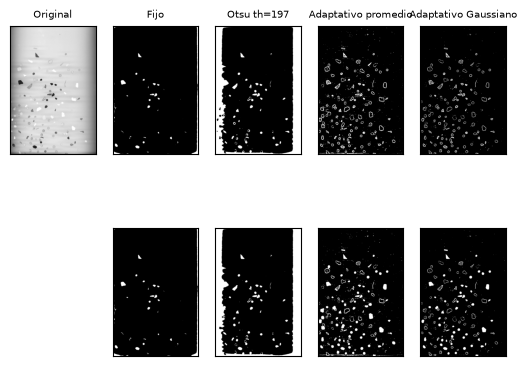

In [13]:
# Carga imagen directamente en grises
imgorig = cv2.imread('MPs_test.jpg', cv2.IMREAD_GRAYSCALE) 

img = cv2.GaussianBlur(imgorig,(5,5),0)

# Umbralizados
ret, imth1 = cv2.threshold(img,150,255,cv2.THRESH_BINARY_INV)
thotsu, imth2 = cv2.threshold(img,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
print('Umbral escogido ', thotsu)

imth3 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,\
            cv2.THRESH_BINARY,11,2)
imth4 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,11,2)
 
titles = ['Original', 'Fijo', 'Otsu th=' + str(int(thotsu)), 'Adaptativo promedio', 'Adaptativo Gaussiano']
images = [img, imth1, imth2, 255 - imth3, 255 - imth4]
 
for i in range(5):
    plt.subplot(2,5,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i], fontsize=7)
    plt.xticks([]),plt.yticks([])

    # Contornos externos
    if i > 0:
        res, imth = cv2.threshold(images[i],120,255,cv2.THRESH_BINARY)
        contornos, hierarchy= cv2.findContours(imth, 
            cv2.RETR_EXTERNAL , 
            cv2.CHAIN_APPROX_SIMPLE
        )  
        img_cont = np.zeros(img.shape)
        cv2.drawContours(img_cont, contornos, -1, (255,255,255), -1)  
        plt.subplot(2,5,i+6),plt.imshow(img_cont,'gray')
        plt.xticks([]),plt.yticks([])

plt.show()

Para esta imagen de muestras de microplásticos tenemos una anotación (que puede contener errores) de la tipología de las partículas. Esta será la imagen de test en los experimentos posteriores.
No puedes hacer uso de esta imagen para entrenar tu clasificador, solo para evaluarlo

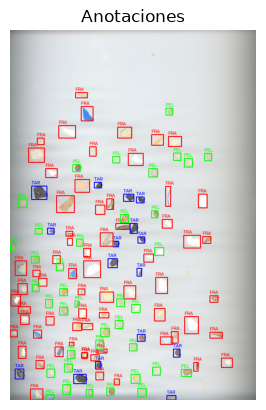

In [14]:
# Imagen y anotaciones
imagen = "MPs_test.jpg"          # Imagen original
csv_file = "MPs_test_bbs.csv"    # CSV con coordenadas y tipología

# Colores de cada clase
colores = {
    "FRA": (0, 0, 255),   # Rojo 
    "PEL": (0, 255, 0),   # Verde
    "TAR": (255, 0, 0)    # Azul
}

# Imagen
img = cv2.imread(imagen)

# Cara csv y dibujar rectángulos
with open(csv_file, newline="") as file:
    reader = csv.DictReader(file)
    for row in reader:
        etiqueta = row["label"]
        x_min, y_min, x_max, y_max = map(int, [row["x_min"], row["y_min"], row["x_max"], row["y_max"]])
        
        # Color según etiqueta
        color = colores.get(etiqueta, (0, 0, 0))  # negro por defecto si no encuentra
        
        # Dibujar rectángulo
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
        
        # Etiqueta 
        cv2.putText(img, etiqueta, (x_min, y_min - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Visualiza resultado
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Anotaciones")
plt.axis('off')
plt.show()


##Muestras de entrenamiento

Text(0.5, 1.0, 'Alquitrán')

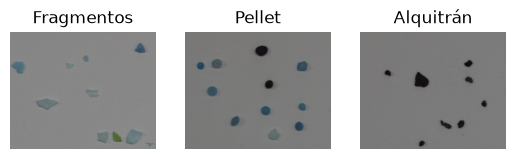

In [15]:
# Cargamos tres subimágenes, por simplicidad, de cada uno de los tres tipos considerados (reiterar que el alquitrán no es microplástico)
imgF = cv2.imread('FRA.png') 
imgP = cv2.imread('PEL.png') 
imgT = cv2.imread('TAR.png') 

plt.subplot(131)
plt.axis("off")
plt.imshow(imgF) 
plt.title('Fragmentos')
plt.subplot(132)
plt.axis("off")
plt.imshow(imgP) 
plt.title('Pellet')
plt.subplot(133)
plt.axis("off")
plt.imshow(imgT) 
plt.title('Alquitrán')

El objetivo de la siguiente tarea, descrita más abajo, es desarrollar tu propio clasificador mediante heurísticas basadas en características geométricas y/o de apariencia, a partir de las imágenes completas de las partículas de cada tipo, debiendo mostrar la bondad del clasificador haciendo uso de métricas para ello sobre las anotaciones de la imagen de test *MPs_test.png*. 

La siguiente celda obtiene varias métricas para un conjunto de datos imaginario (y con etiquetas aleatorias). Si bien las trataremos con más detalle en teoría, muestro un repertorio de ellas, dando más peso a la matriz de confusión. La ejecución de la celda requiere instalar el paquete scikit-learn.

¿Qué es una matriz de confusión?
Se utiliza para mostrar el comportamiento de un clasificador para las distintas clases conocidas, se relacionan las etiquetas de las muestras anotadas frente a las predichas por el clasificador. Se busca una matriz diagonal, pero la perfección es infrecuente.

El siguiente ejemplo, muestra el modo de obtener la matriz de confusión para un hipotético problema con cuatro clases, y valores de anotación (variable y) y predicción (variable y_pred) obtenidos de forma aleatoria.

In [20]:
%pip install seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 6.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 6.1 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.3 MB 6.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.1 MB/s  0:00:01
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.9 MB 10.7 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.9 MB 11.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 11.3 MB/s et

Anotaciones  [2, 2, 0, 3, 1, 2, 2, 0, 0, 1, 0, 2, 1, 2, 3, 3, 1, 0, 0, 0, 3, 3, 3, 0, 0, 1, 3, 0, 3, 3, 0, 0, 1, 3, 3, 1, 3, 3, 3, 0, 1, 0, 2, 2, 3, 3, 3, 2, 3, 1, 0, 2, 2, 2, 2, 2, 2, 0, 1, 3, 1, 1, 3, 0, 3, 2, 1, 3, 1, 1, 3, 0, 3, 0, 2, 0, 1, 2, 3, 3, 0, 0, 1, 3, 0, 0, 3, 0, 2, 0, 2, 3, 2, 2, 2, 2, 0, 3, 3, 1]
Predicciones  [0, 3, 3, 0, 3, 2, 2, 0, 2, 1, 1, 1, 1, 2, 3, 0, 0, 0, 1, 1, 2, 0, 3, 2, 0, 0, 0, 1, 0, 1, 2, 2, 0, 0, 1, 2, 2, 3, 3, 2, 0, 1, 2, 0, 3, 0, 1, 2, 0, 2, 2, 2, 0, 2, 1, 0, 3, 2, 2, 3, 2, 1, 0, 0, 1, 0, 1, 0, 2, 2, 1, 2, 3, 3, 1, 3, 1, 3, 0, 3, 1, 2, 3, 0, 3, 0, 3, 1, 0, 1, 3, 0, 1, 1, 0, 0, 1, 3, 0, 3]
¿Cómo de bien encajan anotación y predicción?
Accuracy (TP/(n))= 0.27
Precision (TP/(TP+FP)) = 0.2986674347158218
Recall (TP/(TP+FN)) = 0.27
F1 Score (2*(precision*recall)/(precision+recall)) = 0.27863963622584315


Text(38.236490885416664, 0.5, 'Real/Anotado')

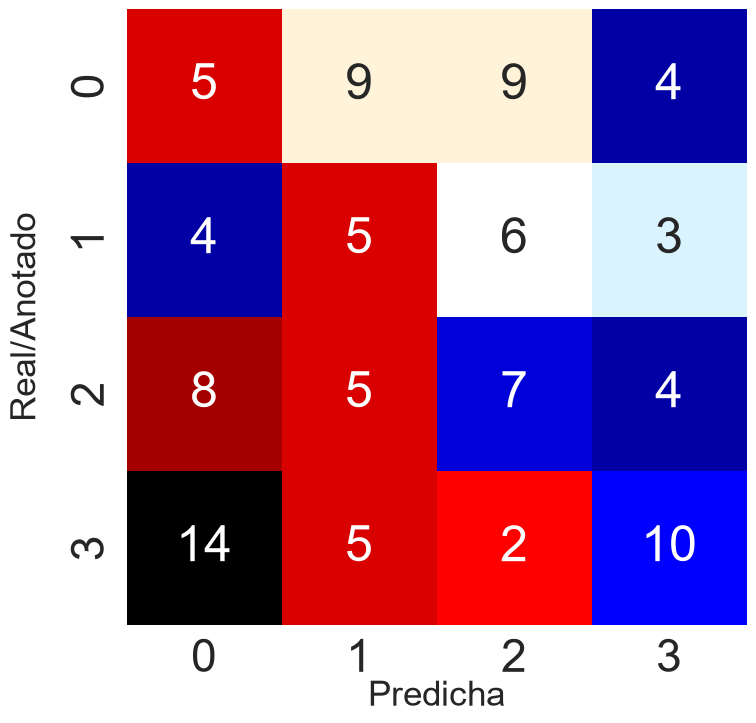

In [21]:

import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)

# Numero de muestras
n = 100  
nclases = 4

# A falta de clasificador y conjunto de datos, creamos anotaciones y predicciones de forma aleatoria
# Vector aleatorio con etiquetas anotadas
y = [random.randint(0, nclases - 1) for _ in range(n)]
print('Anotaciones ' , y)

# Vector aleatorio con etiquetas predichas por un supuesto clasificador
y_pred = [random.randint(0, nclases - 1) for _ in range(n)]
print('Predicciones ' , y_pred)

print('¿Cómo de bien encajan anotación y predicción?')

#Cálculo de métricas
accuracy = accuracy_score(y, y_pred)
#Para más de una clase se define la forma de promediar
precision = precision_score(y, y_pred,average='weighted')
recall = recall_score(y, y_pred,average='weighted')
f1score = f1_score(y, y_pred,average='weighted')

print(f"Accuracy (TP/(n))= {accuracy}")
print(f"Precision (TP/(TP+FP)) = {precision}")
print(f"Recall (TP/(TP+FN)) = {recall}")
print(f"F1 Score (2*(precision*recall)/(precision+recall)) = {f1score}")


conf_matrix = confusion_matrix(y, y_pred)
plt.figure(figsize=(8,8))
sns.set(font_scale = 1.75)#tamaños tipografía
sns.set(font_scale = 3.0)

ax = sns.heatmap(
        conf_matrix, # confusion matrix 2D array 
        annot=True, # Muestra números en las celdas
        fmt='d', # valores enteros
        cbar=False, # sin barra de colores
        cmap='flag', # mapa de colores
        #vmax=175 # contraste de color
    )

#Etiquetas matriz de confusión
label_font = {'size':'25'}
ax.set_xlabel("Predicha", labelpad=-0.75, fontdict=label_font)
ax.set_ylabel("Real/Anotado", labelpad=20, fontdict=label_font)

TAREA: La tarea consiste en extraer características (geométricas y/o visuales) de las tres imágenes completas de partida, y *aprender* patrones que permitan identificar las partículas en nuevas imágenes. 
Para ello se proporciona como imagen de test *MPs_test.jpg* y sus correpondientes anotaciones *MPs_test_bbs.csv* con la que deben obtener las métricas para su propuesta de clasificación de microplásticos, además de la matriz de confusión. 
La matriz de confusión permitirá mostrar para cada clase el número de muestras que se clasifican correctamente de dicha clase, y el número de muestras que se clasifican incorrectamente como perteneciente a una de las otras dos clases. De nuevo, no deben hacer uso de modelos de aprendizaje profundo ni para segmentar, ni para clasificar.

En el trabajo [SMACC: A System for Microplastics Automatic Counting and Classification](https://doi.org/10.1109/ACCESS.2020.2970498), las características geométricas utilizadas fueron:

- Área en píxeles
- Perímetro en píxeles
- Compacidad (relación entre el cuadrado del perímetro y el área de la partícula)
- Relación del área de la partícula con la del contenedor
- Relación del ancho y el alto del contenedor
- Relación entre los ejes de la elipse ajustada
- Definido el centroide, relación entre las distancias menor y mayor al contorno

Si no se quedan satisfechos con la segmentación obtenida, es el mundo real, también en el README comento técnicas recientes de segmentación, que podrían despertar su curiosidad.

IMPORTANTE: No se admite el uso de modelos de aprendizaje profundo